In [5]:
# Import basic libraries
import pandas as pd
import numpy as np

# Upload dataset files
from google.colab import files
uploaded = files.upload()

Saving test.csv to test (1).csv
Saving train.csv to train (1).csv


Load and View Dataset
👉 What this step does:
Read CSV files
Check data structure
Understand columns

In [6]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

train_df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


Rename Columns

In [7]:
train_df.columns = ['Class', 'Title', 'Description']
test_df.columns = ['Class', 'Title', 'Description']

check dataset info

In [8]:
# Check dataset shape
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Check column names
print(train_df.columns)

Train shape: (120000, 3)
Test shape: (7600, 3)
Index(['Class', 'Title', 'Description'], dtype='object')


In [9]:
train_df.columns = ['Class', 'Title', 'Description']
test_df.columns = ['Class', 'Title', 'Description']

Text Preprocessing
👉 What this step does:
Combine Title + Description
Clean text (lowercase, remove symbols)
Remove stopwords
Prepare final text for ML

In [10]:
train_df['text'] = train_df['Title'] + " " + train_df['Description']
test_df['text'] = test_df['Title'] + " " + test_df['Description']

train_df = train_df[['Class', 'text']]
test_df = test_df[['Class', 'text']]

train_df.head()

,Class,text
0,3,Wall St. Bears Claw Back Into the Black (Reute...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...
4,3,"Oil prices soar to all-time record, posing new..."


In [11]:
# Install nltk
!pip install nltk

In [12]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()  # tokenization

    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

# Apply preprocessing
train_df['text'] = train_df['text'].apply(clean_text)
test_df['text'] = test_df['text'].apply(clean_text)

train_df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,Class,text
0,3,wall st bear claw back black reuters reuters s...
1,3,carlyle look toward commercial aerospace reute...
2,3,oil economy cloud stock outlook reuters reuter...
3,3,iraq halt oil export main southern pipeline re...
4,3,oil price soar time record posing new menace u...


TF-IDF Vectorization

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train = tfidf.fit_transform(train_df['text']).toarray()
X_test = tfidf.transform(test_df['text']).toarray()

y_train = train_df['Class']
y_test = test_df['Class']

print(X_train.shape)
lemmatizer = WordNetLemmatizer()

(120000, 5000)


Train Model (Naive Bayes)

In [14]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

Prediction

In [15]:
y_pred = model.predict(X_test)

Evaluation

In [16]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8907894736842106

Classification Report:

              precision    recall  f1-score   support

           1       0.90      0.89      0.89      1900
           2       0.94      0.97      0.96      1900
           3       0.86      0.84      0.85      1900
           4       0.86      0.86      0.86      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



CountVectorizer

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=5000)

X_train_cv = cv.fit_transform(train_df['text']).toarray()
X_test_cv = cv.transform(test_df['text']).toarray()

model_cv = MultinomialNB()
model_cv.fit(X_train_cv, y_train)

y_pred_cv = model_cv.predict(X_test_cv)

print("CountVectorizer Accuracy:", accuracy_score(y_test, y_pred_cv))

CountVectorizer Accuracy: 0.8919736842105264


Confusion Matrix

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[1683   69   96   52]
 [  30 1845   12   13]
 [  81   22 1602  195]
 [  82   26  152 1640]]


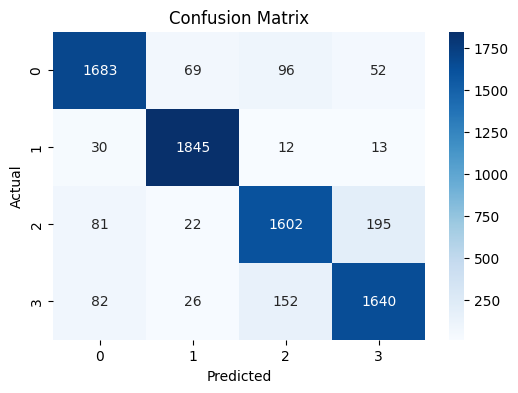

In [19]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()